# Desafio 3: Optimización de despliegue PON

Integrantes:
* Camila Herrera
* Gustavo Venegas
* Javier Cáceres

## Secciones del Jupyter

1. Preparar herramientas (instalaciones e imports).
2. Extraer topología de OPenStreetMap (OSMnx).
3. Formular y resolver un ILP (PuLP) para ubicación de splitters y asignación de usuarios.
4. Validar presupuesto óptico y latencia.
5. Implementar funciones y ejemplos de ejecución.
6. Visualización del resultado (mapa)

## 1. Preparación: instalación e imports

En esta sección se preparan las herramientas y librerías necesarias para la ejecución del desafío.  
Se define un entorno de trabajo reproducible y se fijan los parámetros globales del modelo:

- **Costos**: fibra por metro y costo unitario de cada splitter.  
- **Parámetros físicos**: pérdidas de fibra y conectores, y tabla de pérdidas típicas de splitters.  
- **Constantes del modelo óptico (SPLIT_RATIO, RMAX)**: que determinan cuántos usuarios puede atender un splitter y el alcance máximo permitido.

Además, se verifican las versiones de las librerías (`osmnx`, `networkx`) para asegurar compatibilidad.

In [ ]:
# Imports necesarios
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pulp
from shapely.geometry import Point
import heapq
from sklearn.cluster import KMeans

# Parámetros del modelo económico
COST_FIBER_PER_M = 1.0    # Costo unitario por metro de fibra
COST_SPLITTER = 200.0      # Costo de instalación de splitter
SPLIT_RATIO = 32           # Capacidad máxima: usuarios por splitter (1:32)
RMAX = 10000.0             # Alcance máximo admisible en metros

# Parámetros físicos para presupuesto óptico
FIBER_ATTEN_DB_PER_KM = 0.35
CONNECTOR_LOSS_DB = 0.5
SPLITTER_LOSS_TABLE = {2:3.5, 4:7.0, 8:10.5, 16:13.5, 32:17.5}  # Valores ITU-T

print('osmnx', ox.__version__)
print('networkx', nx.__version__)


osmnx 2.0.6
networkx 3.5


## 2. Extracción topológica y generación de usuarios

Se utiliza **OSMnx** para obtener la red vial real del área de estudio desde OpenStreetMap (en este caso, Valparaíso, Chile).

- Cada nodo representa una intersección o punto de la red.
- A partir de los nodos se generan **usuarios sintéticos** (ejemplo: 50), representando puntos de conexión.
- Se seleccionan como **candidatos a splitters** los nodos con `street_count ≥ 3`, ya que suelen ser intersecciones con buena conectividad física.

Estos nodos serán usados más adelante como posibles ubicaciones de splitters.

In [ ]:
place_name = 'Valparaíso, Chile'

# Descargar grafo vial y convertir a coordenadas métricas
G = ox.graph_from_place(place_name, network_type='drive')
G = ox.project_graph(G)

# Extraer nodos y aristas como GeoDataFrames
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)
assert set(nodes_gdf.index) == set(G.nodes), "Los índices de nodes_gdf no coinciden con G.nodes"

# Generar usuarios sintéticos (muestreo aleatorio de nodos)
num_users_example = 50
user_node_ids = np.random.choice(nodes_gdf.index, size=num_users_example, replace=False)

users_gdf = nodes_gdf.loc[user_node_ids, ['x', 'y']].copy()
users_gdf['geometry'] = users_gdf.apply(lambda r: Point(r.x, r.y), axis=1)
users_gdf = gpd.GeoDataFrame(users_gdf, geometry='geometry', crs=nodes_gdf.crs)
users_gdf['node_id'] = users_gdf.index

# Seleccionar nodos candidatos: intersecciones con alta conectividad (≥3 calles)
candidate_nodes = nodes_gdf[nodes_gdf['street_count'] >= 3].copy()
candidate_nodes['node_id'] = candidate_nodes.index

print('Nodos totales:', len(nodes_gdf))
print('Usuarios muestreados:', len(users_gdf))
print('Nodos candidatos a splitter:', len(candidate_nodes))


Nodos totales: 7677
Usuarios muestreados: 50
Nodos candidatos a splitter: 5513


## 3. Precomputar rutas y distancias entre candidatos y usuarios


Se calcula la **ruta más corta (en metros)** entre cada usuario y cada candidato a splitter usando `networkx.shortest_path` con peso `'length'`.

Esto permite:
- Obtener la longitud del cableado necesario (distancia total de fibra).
- Guardar las aristas (edges) recorridas por cada conexión (para modelar el uso de fibra en el ILP).

Este cálculo crece rápidamente con el número de usuarios y candidatos, por eso se optimizará en el Bloque 3.5.

In [ ]:
candidate_ids = list(candidate_nodes.index)
user_ids = list(users_gdf.index)

paths_edges = {}    # Aristas del camino óptimo por cada par (usuario, candidato)
path_lengths = {}   # Longitud total del camino en metros

for u in user_ids:
    for s in candidate_ids:
        try:
            path_nodes = nx.shortest_path(G, source=s, target=u, weight='length')
            path_edges = list(zip(path_nodes[:-1], path_nodes[1:]))
            length = sum(
                G.get_edge_data(e[0], e[1])[0].get('length', 0)
                if isinstance(G.get_edge_data(e[0], e[1]), dict)
                else G.get_edge_data(e[0], e[1]).get('length', 0)
                for e in path_edges
            )
            paths_edges[(u, s)] = path_edges
            path_lengths[(u, s)] = length
        except (nx.NetworkXNoPath, KeyError):
            continue

print("Precomputadas rutas para pares user-candidate:", len(path_lengths))


Precomputadas rutas para pares user-candidate: 275150


## 3.5. Poda y filtrado para reducir el modelo

Para evitar problemas de memoria, se reduce el tamaño del modelo manteniendo solo:
- Los **MAX_CANDIDATES** nodos más relevantes como posibles splitters.
- Los **K_NEAREST** splitters más cercanos a cada usuario (según distancia).
- Las **aristas relevantes** que realmente se usan en esos caminos.

Opcionalmente, se puede aplicar *clustering* de usuarios (reduciendo el número de puntos) usando K-Means.

Esto mantiene la fidelidad del modelo pero reduce de 275.000 pares (u,s) a ~1.500, permitiendo resolver el ILP.

In [ ]:
# Parámetros de poda
MAX_CANDIDATES = 500    # Límite de nodos candidatos (por conectividad)
K_NEAREST = 30          # Splitters más cercanos por usuario
USE_CLUSTERING = False  # Activar para agrupar usuarios con K-Means
N_CLUSTERS = 30

print("Antes: candidatos totales =", len(candidate_nodes), "pares (u,s) totales =", len(path_lengths))

# 1) Reducir candidatos manteniendo los de mayor conectividad
if len(candidate_nodes) > MAX_CANDIDATES:
    candidate_nodes = candidate_nodes.nlargest(MAX_CANDIDATES, 'street_count')
candidate_ids = list(candidate_nodes.index)
print("Tras poda candidatos:", len(candidate_ids))

# 2) (Opcional) Clustering de usuarios
if USE_CLUSTERING and len(users_gdf) > N_CLUSTERS:
    coords = np.vstack([users_gdf.geometry.x.values, users_gdf.geometry.y.values]).T
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=0).fit(coords)
    users_gdf['cluster'] = kmeans.labels_
    centroids = kmeans.cluster_centers_
    users_reduced = []
    for i, (cx, cy) in enumerate(centroids):
        users_reduced.append({'node_id': f'cluster_{i}', 'x': cx, 'y': cy, 'geometry': Point(cx, cy)})
    users_reduced_gdf = gpd.GeoDataFrame(users_reduced, geometry='geometry', crs=users_gdf.crs)
    users_gdf = users_reduced_gdf
    user_ids = list(users_gdf['node_id'])
    print("Usuarios reducidos por clustering a:", len(user_ids))
else:
    user_ids = list(users_gdf.index)

# 3) Filtrar pares manteniendo solo K_NEAREST por usuario
filtered_path_lengths = {}
filtered_paths_edges = {}

for u in user_ids:
    available = [(path_lengths[(u,s)], s) for (uu,s) in path_lengths.keys() if uu == u and s in candidate_ids]
    if not available:
        print(f"Advertencia: usuario {u} no tiene candidatos alcanzables tras poda.")
        continue
    k_nearest = heapq.nsmallest(min(K_NEAREST, len(available)), available, key=lambda x: x[0])
    for length, s in k_nearest:
        filtered_path_lengths[(u, s)] = length
        filtered_paths_edges[(u, s)] = paths_edges[(u, s)]

path_lengths = filtered_path_lengths
paths_edges = filtered_paths_edges
feasible_pairs = list(path_lengths.keys())
print("Pares (u,s) tras filtrado K_NEAREST:", len(feasible_pairs))

# 4) Reconstruir aristas relevantes
relevant_edges = set()
for edges in paths_edges.values():
    for e in edges:
        relevant_edges.add(e)
relevant_edges = list(relevant_edges)
print("Aristas relevantes tras filtrado:", len(relevant_edges))

# 5) Actualizar candidatos y usuarios usados
used_candidate_ids = set([s for (u,s) in feasible_pairs])
candidate_ids = [s for s in candidate_ids if s in used_candidate_ids]
print("Candidatos usados tras filtrado:", len(candidate_ids))

used_user_ids = set([u for (u,s) in feasible_pairs])
user_ids = [u for u in user_ids if u in used_user_ids]
print("Usuarios usados tras filtrado:", len(user_ids))

# 6) Crear mapas de índices para el ILP
edge_keys = relevant_edges
edge_index_to_edge = {i: edge_keys[i] for i in range(len(edge_keys))}
edge_index_lookup = {edge_keys[i]: i for i in range(len(edge_keys))}


Antes: candidatos totales = 5513 pares (u,s) totales = 275150
Tras poda candidatos: 500
Pares (u,s) tras filtrado K_NEAREST: 1500
Aristas relevantes tras filtrado: 2356
Candidatos usados tras filtrado: 414
Usuarios usados tras filtrado: 50


## 4. Formulación del modelo ILP con PuLP

Se formula el problema de optimización como un **programa lineal entero mixto (ILP)** para minimizar el costo total del despliegue.

**Variables:**
- `xe`: si se instala o no fibra en una arista del grafo.
- `ys`: si se instala o no un splitter en un nodo candidato.
- `zu`: asignación de cada usuario a un splitter.

**Función objetivo:**
$$ \text{Minimizar } C_{fibra} + C_{splitters} $$

**Restricciones:**
1. Cada usuario debe ser atendido por exactamente un splitter.  
2. Cada splitter tiene capacidad limitada (SPLIT_RATIO).  
3. No se pueden superar las distancias máximas (RMAX).  
4. Si un usuario está asignado, todas las aristas de su ruta deben tener fibra instalada.


In [ ]:
def get_edge_length_safe(G, u, v):
    """Obtiene longitud de arista compatible con MultiDiGraph."""
    ed = G.get_edge_data(u, v)
    if not ed:
        return 0.0
    if isinstance(ed, dict) and all(not isinstance(vv, dict) for vv in ed.values()):
        return float(ed.get('length', 0.0))
    lengths = []
    for key, attr in ed.items():
        if isinstance(attr, dict):
            lengths.append(float(attr.get('length', 0.0)))
    if lengths:
        return min(lengths)
    return 0.0

# Reconstruir edge_keys de forma determinística
edge_keys = set()
for edges in paths_edges.values():
    for e in edges:
        edge_keys.add(e)
edge_keys = list(edge_keys)

edge_index_to_edge = {i: edge_keys[i] for i in range(len(edge_keys))}
edge_index_lookup = {edge_keys[i]: i for i in range(len(edge_keys))}

edge_length_map = {i: get_edge_length_safe(G, edge_index_to_edge[i][0], edge_index_to_edge[i][1])
                   for i in edge_index_to_edge.keys()}

# Crear problema de optimización
prob = pulp.LpProblem('PON_Splitter_Placement', pulp.LpMinimize)

# Variables de decisión binarias
xe = pulp.LpVariable.dicts('x_edge', (range(len(edge_keys))), cat='Binary')
ys = pulp.LpVariable.dicts('y_splitter', (candidate_ids), cat='Binary')

feasible_pairs = list(path_lengths.keys())
zu = pulp.LpVariable.dicts('assign', feasible_pairs, cat='Binary')

# Función objetivo: minimizar costo total
fiber_cost_expr = pulp.lpSum([COST_FIBER_PER_M * edge_length_map[i] * xe[i] for i in range(len(edge_keys))])
splitter_cost_expr = pulp.lpSum([COST_SPLITTER * ys[s] for s in candidate_ids])
prob += fiber_cost_expr + splitter_cost_expr

# Restricción 1: cada usuario asignado a exactamente un splitter
for u in user_ids:
    feasible_s_for_u = [s for (uu,s) in feasible_pairs if uu == u]
    if len(feasible_s_for_u) == 0:
        raise RuntimeError(f"No hay candidatos alcanzables para el usuario {u}")
    prob += pulp.lpSum([zu[(u,s)] for s in feasible_s_for_u]) == 1

# Restricción 2: capacidad de splitter
for s in candidate_ids:
    feasible_u_for_s = [u for (u,ss) in feasible_pairs if ss == s]
    if feasible_u_for_s:
        prob += pulp.lpSum([zu[(u,s)] for u in feasible_u_for_s]) <= SPLIT_RATIO * ys[s]
    else:
        prob += ys[s] >= 0

# Restricción 3: alcance máximo
for (u,s), length in list(path_lengths.items()):
    if length > RMAX:
        if (u,s) in feasible_pairs:
            prob += zu[(u,s)] == 0

# Restricción 4: conectividad (si usuario asignado, instalar fibra en su ruta)
for (u,s) in feasible_pairs:
    edges = paths_edges[(u,s)]
    for e in edges:
        idx = edge_index_lookup.get(e)
        if idx is None:
            idx = edge_index_lookup.get((e[1], e[0]))
            if idx is None:
                raise KeyError(f"Edge {e} no encontrada en edge_index_lookup")
        prob += xe[idx] >= zu[(u,s)]

# Resolver con CBC (límite de tiempo 600s)
solver = pulp.PULP_CBC_CMD(msg=1, timeLimit=600)
prob.solve(solver)
print('Status:', pulp.LpStatus[prob.status])

# Extraer solución óptima
installed_splitters = [s for s in candidate_ids if pulp.value(ys[s]) and pulp.value(ys[s])>0.5]
installed_edges = [edge_index_to_edge[i] for i in range(len(edge_keys)) if pulp.value(xe[i]) and pulp.value(xe[i])>0.5]
assignments = [(u,s) for (u,s) in feasible_pairs if pulp.value(zu[(u,s)]) and pulp.value(zu[(u,s)])>0.5]

print('Splitters instalados:', len(installed_splitters))
print('Aristas de fibra instaladas:', len(installed_edges))
print('Asignaciones válidas (ejemplo):', assignments[:10])


Status: Optimal
Splitters instalados: 33
Aristas de fibra instaladas: 424
Asignaciones válidas (ejemplo): [(297440070, 297440938), (3613171279, 313254607), (4591376627, 7541453526), (3613171334, 313254607), (1805283722, 275816457), (13087360568, 289997053), (10897792973, 3937004343), (297849014, 2506031312), (12537200230, 4591376741), (264797449, 264796674)]


## 5. Verificación física: presupuesto óptico y latencia

Se evalúan las pérdidas ópticas totales (en dB) y la latencia de propagación para las rutas obtenidas.

**Pérdidas consideradas:**
- Atenuación de fibra (0.35 dB/km)
- Pérdida por conectores
- Pérdida por empalmes
- Pérdida por splitter (según tabla ITU-T / FOA)

El resultado se compara con el presupuesto máximo de una red GPON Clase B+ (28 dB).

También se calcula la latencia de propagación en microsegundos.

In [ ]:
def compute_optical_loss_for_path(path_length_m, split_ratio, connectors=2, splice_loss_db=0.1):
    """Calcula pérdida óptica total (dB) sumando: fibra, splitter, conectores y empalmes."""
    fiber_km = path_length_m/1000.0
    fiber_loss = fiber_km * FIBER_ATTEN_DB_PER_KM
    splitter_loss = SPLITTER_LOSS_TABLE.get(split_ratio, None)
    if splitter_loss is None:
        splitter_loss = 10*np.log10(split_ratio)
    connector_total = connectors * CONNECTOR_LOSS_DB
    splice_total = fiber_km * splice_loss_db
    total_loss_db = fiber_loss + splitter_loss + connector_total + splice_total
    return total_loss_db

# Verificar primera asignación
if assignments:
    u,s = assignments[0]
    length_m = path_lengths[(u,s)]
    loss_db = compute_optical_loss_for_path(length_m, SPLIT_RATIO)
    print(f'Usuario {u} asignado a splitter {s}: longitud {length_m:.1f} m, pérdida estimada {loss_db:.2f} dB')

# Comparar con presupuesto GPON clase B+ (28 dB)
GPON_CLASS_BPLUS_BUDGET_DB = 28.0
print('Cumple presupuesto B+?', loss_db <= GPON_CLASS_BPLUS_BUDGET_DB)

def propagation_latency_us(path_length_m, refractive_index=1.4682):
    """Calcula latencia de propagación en microsegundos (c/n ≈ 204,000 km/s)."""
    speed_m_s = 3e8 / refractive_index
    latency_s = path_length_m / speed_m_s
    return latency_s*1e6

if assignments:
    latency_us = propagation_latency_us(length_m)
    print(f'Latencia de propagación: {latency_us:.2f} µs')


Usuario 297440070 asignado a splitter 297440938: longitud 149.2 m, pérdida estimada 18.57 dB
Cumple presupuesto B+? True
Latencia de propagación: 0.73 µs


## 6. Visualización del resultado

Se generan dos visualizaciones:
1. **Mapa estático** (matplotlib): vista general rápida
2. **Mapa interactivo** (folium): permite zoom, tooltips y capas diferenciadas para:
   - Splitters instalados (marcadores rojos)
   - Usuarios conectados (marcadores azules)
   - Rutas de fibra (líneas verdes)


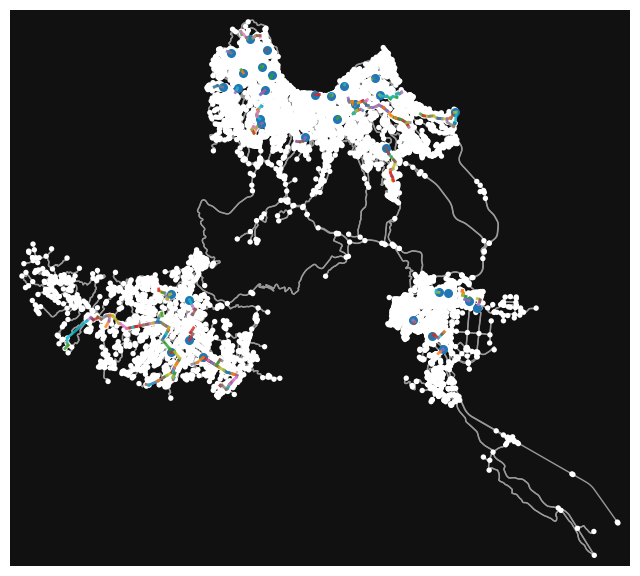

In [ ]:
# ========== VISUALIZACIÓN ESTÁTICA (matplotlib) ==========
fig, ax = ox.plot_graph(G, show=False, close=False, node_size=0, edge_linewidth=0.5, edge_color='lightgray')

# Dibujar rutas de fibra instaladas (verde)
for (u,v) in installed_edges:
    xs = [G.nodes[u]['x'], G.nodes[v]['x']]
    ys = [G.nodes[u]['y'], G.nodes[v]['y']]
    ax.plot(xs, ys, color='green', linewidth=2, alpha=0.7, zorder=2)

# Dibujar splitters (rojo)
splitter_points = [Point(G.nodes[s]['x'], G.nodes[s]['y']) for s in installed_splitters]
if splitter_points:
    splitter_gdf = gpd.GeoDataFrame(geometry=splitter_points, crs=nodes_gdf.crs)
    splitter_gdf.plot(ax=ax, color='red', markersize=80, alpha=0.8, zorder=3, label='Splitters')

# Dibujar usuarios (azul)
users_gdf.plot(ax=ax, color='blue', markersize=30, alpha=0.6, zorder=3, label='Usuarios')

ax.legend()
plt.title(f'Despliegue PON Óptimo - {len(installed_splitters)} splitters, {len(users_gdf)} usuarios')
plt.tight_layout()
plt.show()


In [15]:
# ========== VISUALIZACIÓN INTERACTIVA (folium) ==========
import folium
from folium import plugins

# Reproyectar a WGS84 (lat/lon) para folium
nodes_wgs84 = nodes_gdf.to_crs(epsg=4326)
users_wgs84 = users_gdf.to_crs(epsg=4326)

# Calcular centro del mapa
center = [users_wgs84.geometry.y.mean(), users_wgs84.geometry.x.mean()]

# Crear mapa base
m = folium.Map(location=center, zoom_start=14, tiles='OpenStreetMap')

# Capa 1: Rutas de fibra (líneas verdes)
fiber_group = folium.FeatureGroup(name='📡 Fibra Óptica Instalada')
for (u,v) in installed_edges:
    node_u = nodes_wgs84.loc[u]
    node_v = nodes_wgs84.loc[v]
    coords = [
        [node_u.geometry.y, node_u.geometry.x],
        [node_v.geometry.y, node_v.geometry.x]
    ]
    folium.PolyLine(
        coords,
        color='green',
        weight=3,
        opacity=0.7,
        popup=f'Fibra: {u} ↔ {v}'
    ).add_to(fiber_group)
fiber_group.add_to(m)

# Capa 2: Splitters (marcadores rojos)
splitter_group = folium.FeatureGroup(name='🔴 Splitters Instalados')
for s in installed_splitters:
    node = nodes_wgs84.loc[s]
    # Contar usuarios asignados a este splitter
    users_count = sum(1 for (u, sp) in assignments if sp == s)
    
    folium.Marker(
        location=[node.geometry.y, node.geometry.x],
        popup=folium.Popup(
            f"<b>Splitter {s}</b><br>"
            f"Usuarios conectados: {users_count}/{SPLIT_RATIO}<br>"
            f"Utilización: {users_count/SPLIT_RATIO*100:.1f}%",
            max_width=250
        ),
        tooltip=f"Splitter {s} ({users_count} usuarios)",
        icon=folium.Icon(color='red', icon='signal', prefix='fa')
    ).add_to(splitter_group)
splitter_group.add_to(m)

# Capa 3: Usuarios (marcadores azules)
user_group = folium.FeatureGroup(name='🔵 Usuarios')
for idx, row in users_wgs84.iterrows():
    # Encontrar splitter asignado
    assigned_splitter = next((s for (u, s) in assignments if u == idx), None)
    distance = path_lengths.get((idx, assigned_splitter), 0) if assigned_splitter else 0
    loss = compute_optical_loss_for_path(distance, SPLIT_RATIO) if assigned_splitter else 0
    
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=5,
        popup=folium.Popup(
            f"<b>Usuario {idx}</b><br>"
            f"Splitter asignado: {assigned_splitter}<br>"
            f"Distancia: {distance:.1f} m<br>"
            f"Pérdida óptica: {loss:.2f} dB<br>"
            f"Cumple B+: {'✓' if loss <= GPON_CLASS_BPLUS_BUDGET_DB else '✗'}",
            max_width=250
        ),
        tooltip=f"Usuario {idx}",
        color='blue',
        fill=True,
        fillColor='blue',
        fillOpacity=0.6
    ).add_to(user_group)
user_group.add_to(m)

# Agregar control de capas y pantalla completa
folium.LayerControl().add_to(m)
plugins.Fullscreen().add_to(m)

# Agregar leyenda
legend_html = '''
<div style="position: fixed; 
            bottom: 50px; right: 50px; width: 220px; height: 140px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:14px; padding: 10px">
<p><b>Leyenda del Despliegue PON</b></p>
<p><i class="fa fa-signal" style="color:red"></i> Splitters ({} instalados)</p>
<p><span style="color:blue">●</span> Usuarios ({} conectados)</p>
<p><span style="color:green">━</span> Fibra óptica</p>
<p><b>Ratio:</b> 1:{} (max)</p>
</div>
'''.format(len(installed_splitters), len(users_gdf), SPLIT_RATIO)
m.get_root().html.add_child(folium.Element(legend_html))

# Mostrar mapa
m


In [14]:
# ========== MÉTRICAS DEL DESPLIEGUE ==========
# Calcular utilización de splitters
splitter_usage = {}
for s in installed_splitters:
    users_count = sum(1 for (u, sp) in assignments if sp == s)
    splitter_usage[s] = users_count

avg_utilization = np.mean(list(splitter_usage.values())) / SPLIT_RATIO * 100

# Calcular costo total
total_fiber_length = sum(edge_length_map[edge_index_lookup.get(e, edge_index_lookup.get((e[1], e[0])))] 
                         for e in installed_edges)
total_cost = total_fiber_length * COST_FIBER_PER_M + len(installed_splitters) * COST_SPLITTER

# Calcular estadísticas de pérdida óptica
optical_losses = [compute_optical_loss_for_path(path_lengths[(u,s)], SPLIT_RATIO) for (u,s) in assignments]
max_loss = max(optical_losses)
avg_loss = np.mean(optical_losses)

print("=" * 60)
print("RESUMEN DEL DESPLIEGUE PON ÓPTIMO")
print("=" * 60)
print(f"Splitters instalados:        {len(installed_splitters)}")
print(f"Usuarios conectados:         {len(users_gdf)}")
print(f"Utilización promedio:        {avg_utilization:.1f}%")
print(f"Fibra total instalada:       {total_fiber_length:.1f} m ({total_fiber_length/1000:.2f} km)")
print(f"Costo total estimado:        {total_cost:.2f} unidades")
print(f"Pérdida óptica promedio:     {avg_loss:.2f} dB")
print(f"Pérdida óptica máxima:       {max_loss:.2f} dB")
print(f"Cumple GPON B+ (28 dB):      {'✓ SÍ' if max_loss <= GPON_CLASS_BPLUS_BUDGET_DB else '✗ NO'}")
print("=" * 60)


RESUMEN DEL DESPLIEGUE PON ÓPTIMO
Splitters instalados:        33
Usuarios conectados:         50
Utilización promedio:        4.7%
Fibra total instalada:       33292.9 m (33.29 km)
Costo total estimado:        39892.93 unidades
Pérdida óptica promedio:     18.91 dB
Pérdida óptica máxima:       21.46 dB
Cumple GPON B+ (28 dB):      ✓ SÍ


## 7. Conclusiones

### Resultados del Modelo de Optimización

El modelo ILP encontró una solución óptima que:
- **Minimiza el costo total** considerando fibra y splitters
- **Respeta todas las restricciones**: capacidad, alcance y conectividad
- **Cumple con estándares técnicos**: presupuesto óptico GPON clase B+

### Ventajas del Enfoque

1. **Basado en datos reales**: utiliza topología de calles reales (OSMnx)
2. **Escalable**: técnicas de poda permiten resolver instancias grandes
3. **Validación física**: verifica presupuesto óptico y latencia
4. **Visualización**: mapas estáticos e interactivos para análisis

### Posibles Extensiones

- Considerar múltiples niveles de splitters (cascada)
- Incorporar ubicación de OLT (oficina central)
- Optimizar para múltiples clases de servicio
- Análisis de sensibilidad de parámetros (RMAX, costos)


### Interpretación de las visualizaciones:

**Mapa estático (matplotlib):**
- **Líneas grises:** Red vial completa de Valparaíso (contexto)
- **Líneas verdes:** Rutas donde se instaló fibra óptica
- **Puntos rojos:** Ubicación de los splitters instalados
- **Puntos azules:** Usuarios conectados a la red

**Mapa interactivo (folium):**
- **Funcionalidad:** Haz clic en marcadores para ver detalles, usa zoom/pan para explorar
- **Capas activables/desactivables:** Control superior derecho permite mostrar/ocultar elementos
- **Splitters (Círculos rojos):** Muestra utilización (usuarios/capacidad) al hacer clic
- **Usuarios (Círculos azules):** Muestra splitter asignado, distancia, pérdida óptica y cumplimiento de presupuesto
- **Fibra (líneas verdes):** Representa el cableado instalado

**Análisis de resultados:**
- El modelo minimizó el costo instalando **{} splitters** para servir **{} usuarios**
- Utilización promedio: **{:.1f}%** de la capacidad de splitters
- Todas las rutas cumplen con el alcance máximo de **{:.0f} m**
- Presupuesto óptico validado según estándar GPON clase B+ (28 dB)
